# Deep Learning Project : Classifiers

## Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import cv2
import os
import re

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from models.classifiers.NN.NN_1 import DeepFakeNN_1
from models.classifiers.CNN.ResNet34 import DeepFakeResNet34
from models.classifiers.CNN.Xception import DeepFakeXception
from models.classifiers.CNN.EfficientNet import DeepFakeEfficientNet

## Load Dataset

In [2]:
#  Grab all the real images from the 'wiki' folder
real_images = glob("data/wiki/**/*.jpg", recursive=True)

# Grab all the fake images from the other three folders
fake_images_dict = {}
total_fake_count = 0
for folder in ["inpainting", "insight", "text2img"]:
    paths = glob(f"data/{folder}/**/*.jpg", recursive=True)
    fake_images_dict[folder] = paths
    total_fake_count += len(paths)

print(f"Total Real Images found: {len(real_images)}")
print(f"Total Fake Images found: {total_fake_count}")

for folder, paths in fake_images_dict.items():
    print(f"  - {folder}: {len(paths)}")

Total Real Images found: 30000
Total Fake Images found: 90000
  - inpainting: 30000
  - insight: 30000
  - text2img: 30000


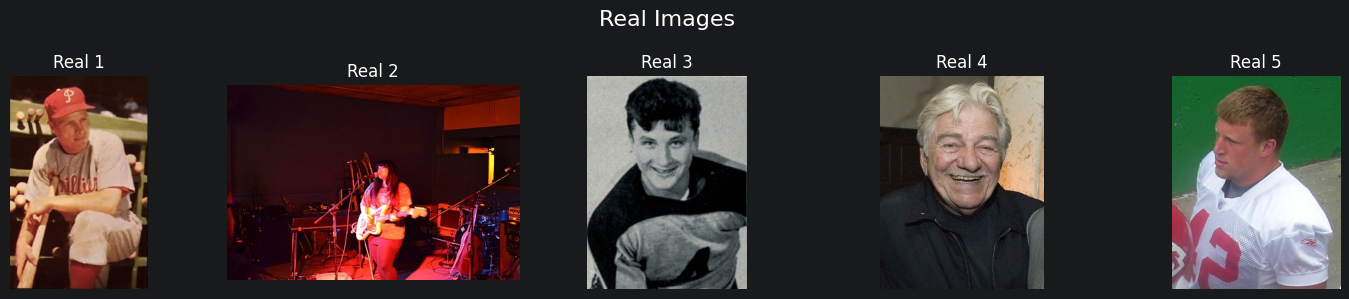

In [3]:
first_5_real = real_images[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Real Images", fontsize=16)

for i, path in enumerate(first_5_real):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Real {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

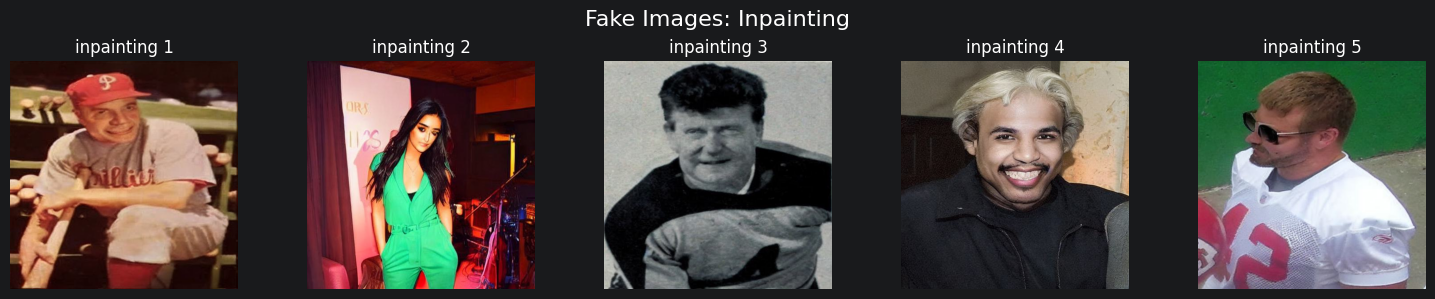

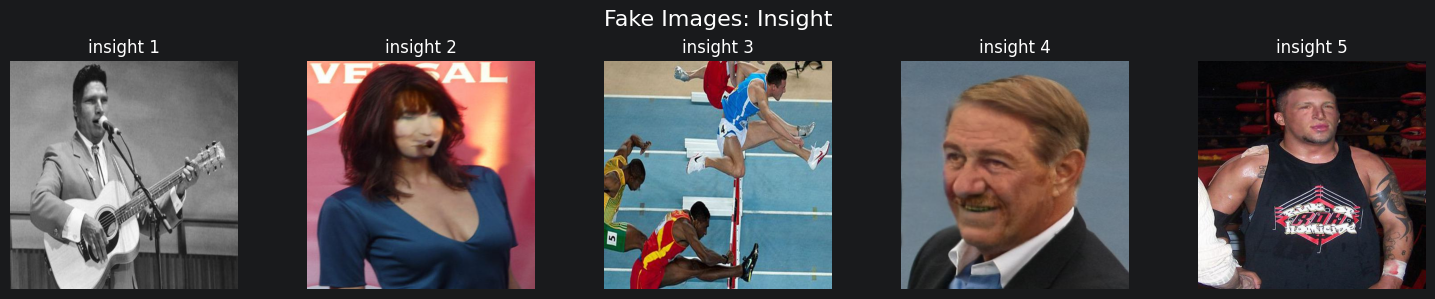

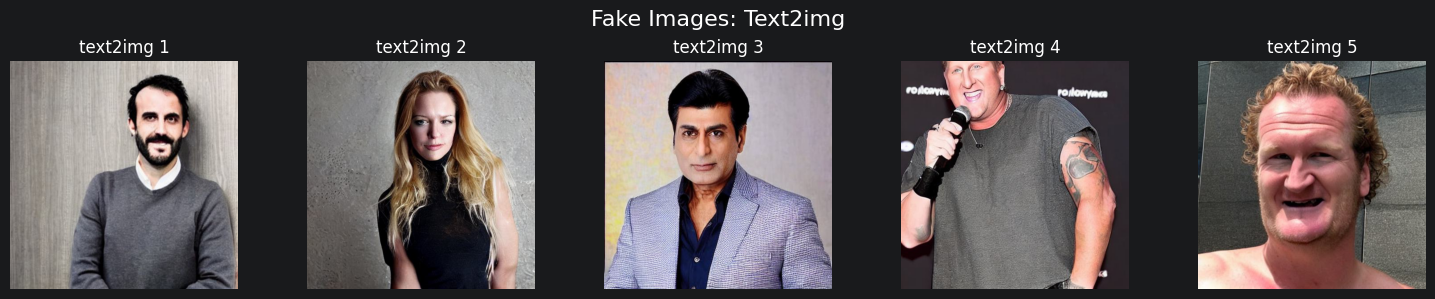

In [4]:
for folder_name, paths in fake_images_dict.items():

    first_5_category = paths[:5]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Fake Images: {folder_name.capitalize()}", fontsize=16)

    for i, path in enumerate(first_5_category):
        img = cv2.imread(path)

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)

        axes[i].set_title(f"{folder_name} {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Preprocessing

In [5]:
class DeepFakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'filepath']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([label], dtype=torch.float32)

        return image, label

In [6]:
def create_preprocessing_pipeline(real_list, fake_dict, batch_size=32, img_size=(224, 224), fake_index=3, model_type=None, balance=False):
    """
    Takes lists of real and fake images, builds dataframes, splits the data,
    and returns PyTorch DataLoaders and the split DataFrames.

    fake_index:
        0 = use first fake category
        1 = use second fake category
        2 = use third fake category
        3 = use ALL fake categories

    model_type:
        'resnet'   -> Applies ImageNet mean/std normalization
        'xception' -> Applies Xception [-1, 1] normalization
        None       -> No extra normalization (use for custom CNNs)

    balance:
        True  -> Undersample fakes to match real count (recommended for fake_index=3)
        False -> Use all available data as-is
    """

    print("Building DataFrames...")
    # Create Real DataFrame
    df_real = pd.DataFrame({'filepath': real_list, 'label': 0, 'source': 'wiki'})

    # Determine which fake folders to use based on fake_index
    folder_names = list(fake_dict.keys())

    if fake_index == 3:
        folders_to_use = folder_names
        print("Using ALL fake categories.")
    elif 0 <= fake_index <= 2:
        folders_to_use = [folder_names[fake_index]]
        print(f"Using ONLY fake category: {folders_to_use[0]}")
    else:
        raise ValueError("fake_index must be 0, 1, 2, or 3")

    # Create Fake DataFrame
    fake_dfs = []
    for folder_name in folders_to_use:
        paths = fake_dict[folder_name]
        df = pd.DataFrame({'filepath': paths, 'label': 1, 'source': folder_name})
        fake_dfs.append(df)

    df_fake = pd.concat(fake_dfs, ignore_index=True)

    if balance and fake_index == 3:
        print(f"Balancing: sampling evenly from each fake category...")
        n_per_folder = len(df_real) // len(folders_to_use)
        balanced_dfs = []
        for folder_name in folders_to_use:
            df_folder = df_fake[df_fake['source'] == folder_name]
            sampled = df_folder.sample(n=min(n_per_folder, len(df_folder)), random_state=42)
            balanced_dfs.append(sampled)
            print(f"  - {folder_name}: {len(sampled)} samples")
        df_fake = pd.concat(balanced_dfs, ignore_index=True)

    # Combine into full dataset
    df_full = pd.concat([df_real, df_fake], ignore_index=True)

    print("Splitting Data (70% Train, 15% Val, 15% Test)...")
    train_df, temp_df = train_test_split(
        df_full, test_size=0.30, random_state=42, stratify=df_full['label']
    )

    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
    )

    print("Setting up Transforms and DataLoaders...")

    transform_list : list = [
        transforms.Resize(img_size),
        transforms.ToTensor()
    ]

    # Apply specific normalization based on model_type
    if model_type == 'resnet':
        print(" -> Applying ImageNet Normalization for ResNet.")
        transform_list.append(
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        )
    elif model_type == 'xception':
        print(" -> Applying Xception [-1, 1] Normalization.")
        transform_list.append(
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
        )
    else:
        print(" -> No additional normalization applied.")

    data_transform = transforms.Compose(transform_list)

    # Create Datasets
    train_dataset = DeepFakeDataset(train_df, transform=data_transform)
    val_dataset = DeepFakeDataset(val_df, transform=data_transform)
    test_dataset = DeepFakeDataset(test_df, transform=data_transform)

    # Create DataLoaders
    use_pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=use_pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=4, pin_memory=use_pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=4, pin_memory=use_pin_memory)

    print("Pipeline Complete!\n")

    return train_loader, val_loader, test_loader, train_df, val_df, test_df

## Model Training

In [7]:
def compute_binary_metrics(all_labels, all_preds, all_probs):
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

In [8]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(data_loader)
    metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return metrics


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, experiment_name, model_name, base_log_dir="experiment_logs", epochs=5):
    print(f"Starting experiment: {experiment_name}")

    history = {
        "train_loss": [], "train_accuracy": [], "train_precision": [],
        "train_recall": [], "train_f1": [], "train_roc_auc": [],
        "train_tp": [], "train_tn": [], "train_fp": [], "train_fn": [],
        "val_loss": [], "val_accuracy": [], "val_precision": [],
        "val_recall": [], "val_f1": [], "val_roc_auc": [],
        "val_tp": [], "val_tn": [], "val_fp": [], "val_fn": []
    }

    model_dir = os.path.join(base_log_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    log_filepath = os.path.join(model_dir, "logs.txt")
    model_filepath = os.path.join(model_dir, f"model_{experiment_name}.pth")

    with open(log_filepath, "a") as f:
        f.write(f"Experiment: {experiment_name}\n")
        f.write("-" * 40 + "\n")
        f.flush()

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0

            all_labels = []
            all_preds = []
            all_probs = []

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                if labels.dim() == 1:
                    labels = labels.unsqueeze(1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                probs = torch.sigmoid(outputs)
                preds = (probs >= 0.5).float()

                all_labels.extend(labels.detach().cpu().numpy().flatten())
                all_preds.extend(preds.detach().cpu().numpy().flatten())
                all_probs.extend(probs.detach().cpu().numpy().flatten())

            train_loss = running_loss / len(train_loader)
            train_metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
            train_metrics["loss"] = train_loss

            val_metrics = evaluate_model(model, val_loader, criterion, device)

            history["train_loss"].append(train_metrics["loss"])
            history["train_accuracy"].append(train_metrics["accuracy"])
            history["train_precision"].append(train_metrics["precision"])
            history["train_recall"].append(train_metrics["recall"])
            history["train_f1"].append(train_metrics["f1"])
            history["train_roc_auc"].append(train_metrics["roc_auc"])
            history["train_tp"].append(train_metrics["tp"])
            history["train_tn"].append(train_metrics["tn"])
            history["train_fp"].append(train_metrics["fp"])
            history["train_fn"].append(train_metrics["fn"])

            history["val_loss"].append(val_metrics["loss"])
            history["val_accuracy"].append(val_metrics["accuracy"])
            history["val_precision"].append(val_metrics["precision"])
            history["val_recall"].append(val_metrics["recall"])
            history["val_f1"].append(val_metrics["f1"])
            history["val_roc_auc"].append(val_metrics["roc_auc"])
            history["val_tp"].append(val_metrics["tp"])
            history["val_tn"].append(val_metrics["tn"])
            history["val_fp"].append(val_metrics["fp"])
            history["val_fn"].append(val_metrics["fn"])

            log_entry = (
                f"Epoch {epoch+1}:\n"
                f"  TRAIN -> Loss {train_metrics['loss']:.4f}, Accuracy {train_metrics['accuracy']:.2f}%, Precision {train_metrics['precision']:.4f}, Recall {train_metrics['recall']:.4f}, F1 {train_metrics['f1']:.4f}, ROC-AUC {train_metrics['roc_auc']:.4f}, TP {train_metrics['tp']}, TN {train_metrics['tn']}, FP {train_metrics['fp']}, FN {train_metrics['fn']}\n"
                f"  VAL   -> Loss {val_metrics['loss']:.4f}, Accuracy {val_metrics['accuracy']:.2f}%, Precision {val_metrics['precision']:.4f}, Recall {val_metrics['recall']:.4f}, F1 {val_metrics['f1']:.4f}, ROC-AUC {val_metrics['roc_auc']:.4f}, TP {val_metrics['tp']}, TN {val_metrics['tn']}, FP {val_metrics['fp']}, FN {val_metrics['fn']}\n"
            )
            f.write(log_entry)
            f.flush()

            print(f"Finished {log_entry.strip()}")

    torch.save(model.state_dict(), model_filepath)
    print(f"\nTraining complete. Model weights saved to: {model_filepath}")
    print(f"Logs saved to: {log_filepath}")

    return model, history

## Results Visualization Helpers

In [10]:
def parse_experiment_logs(log_filepath):
    """
    Reads a log text file and reconstructs the histories and test metrics
    dictionaries for plotting.
    """
    parsed_histories = {}
    parsed_test_metrics = {}
    current_experiment = None

    if not os.path.exists(log_filepath):
        print(f"Log file not found at {log_filepath}")
        return parsed_histories, parsed_test_metrics

    with open(log_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Detect a new experiment block
            if line.startswith("Experiment:"):
                current_experiment = line.split("Experiment:")[1].strip()
                parsed_histories[current_experiment] = {
                    "train_loss": [], "val_loss": [],
                    "train_accuracy": [], "val_accuracy": []
                }

            # Extract Train metrics
            elif "TRAIN ->" in line and current_experiment:
                loss_match = re.search(r"Loss ([\d\.]+)", line)
                acc_match = re.search(r"Accuracy ([\d\.]+)", line)
                if loss_match and acc_match:
                    parsed_histories[current_experiment]["train_loss"].append(float(loss_match.group(1)))
                    parsed_histories[current_experiment]["train_accuracy"].append(float(acc_match.group(1)))

            # Extract Validation metrics
            elif "VAL   ->" in line and current_experiment:
                loss_match = re.search(r"Loss ([\d\.]+)", line)
                acc_match = re.search(r"Accuracy ([\d\.]+)", line)
                if loss_match and acc_match:
                    parsed_histories[current_experiment]["val_loss"].append(float(loss_match.group(1)))
                    parsed_histories[current_experiment]["val_accuracy"].append(float(acc_match.group(1)))

            # Extract Test metrics
            elif "TEST  ->" in line and current_experiment:
                loss_match = re.search(r"Loss ([\d\.]+)", line)
                acc_match = re.search(r"Accuracy ([\d\.]+)", line)
                if loss_match and acc_match:
                    parsed_test_metrics[current_experiment] = {
                        "loss": float(loss_match.group(1)),
                        "accuracy": float(acc_match.group(1))
                    }

    return parsed_histories, parsed_test_metrics

In [11]:
def plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=None):
    """
    Plots training results. Can either use in-memory dictionaries
    or parse the logs directly from a file.
    """
    # If a file path is provided, parse the logs to get the data
    if log_filepath:
        print(f"Fetching plot data directly from logs: {log_filepath}")
        histories_dict, test_metrics_dict = parse_experiment_logs(log_filepath)

    if not histories_dict:
        print("No history data available to plot.")
        return

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    experiments = list(histories_dict.keys())
    test_accuracies = []

    for experiment_name in experiments:
        history = histories_dict[experiment_name]

        if not history['train_loss']:
            test_accuracies.append(0)
            continue

        epochs = range(1, len(history['train_loss']) + 1)

        # Plot training and validation loss
        ax1.plot(epochs, history['train_loss'], label=f'{experiment_name} Train')
        ax1.plot(epochs, history['val_loss'], linestyle='--', label=f'{experiment_name} Val')

        # Plot training and validation accuracy
        ax2.plot(epochs, history['train_accuracy'], label=f'{experiment_name} Train')
        ax2.plot(epochs, history['val_accuracy'], linestyle='--', label=f'{experiment_name} Val')

        if test_metrics_dict and experiment_name in test_metrics_dict:
            test_accuracies.append(test_metrics_dict[experiment_name]["accuracy"])
        else:
            test_accuracies.append(0)

    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    ax2.set_title('Accuracy over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)

    if any(test_accuracies):
        bars = ax3.bar(experiments, test_accuracies, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
        ax3.set_title('Final Test Accuracy')
        ax3.set_ylabel('Accuracy (%)')
        ax3.set_ylim(0, max(100, max(test_accuracies) + 10))


        for bar in bars:
            height = bar.get_height()
            ax3.annotate(f'{height:.2f}%',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),
                         textcoords="offset points",
                         ha='center', va='bottom')
    else:
        ax3.text(0.5, 0.5, 'No Test Data Available', ha='center', va='center', transform=ax3.transAxes)

    plt.tight_layout()
    plt.show()

### NN

#### NN_1

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_models = {}
all_histories = {}
all_test_metrics = {}
model_name = "NN_1"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (64,64)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    # Check if we should skip
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    # Create the data pipeline
    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeNN_1(img_size).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_models[experiment_name] = trained_model
    all_histories[experiment_name] = train_history
    all_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 EXPERIMENTS COMPLETED SUCESSFULLY!")

Using device: cuda
Skipping INPAINTING: Results already found in experiment_logs/NN_1/logs.txt
Skipping INSIGHT: Results already found in experiment_logs/NN_1/logs.txt
Skipping TEXT2IMG: Results already found in experiment_logs/NN_1/logs.txt
Skipping ALL_FAKES: Results already found in experiment_logs/NN_1/logs.txt

 ALL 4 EXPERIMENTS COMPLETED SUCESSFULLY!


Fetching plot data directly from logs: experiment_logs/NN_1/logs.txt


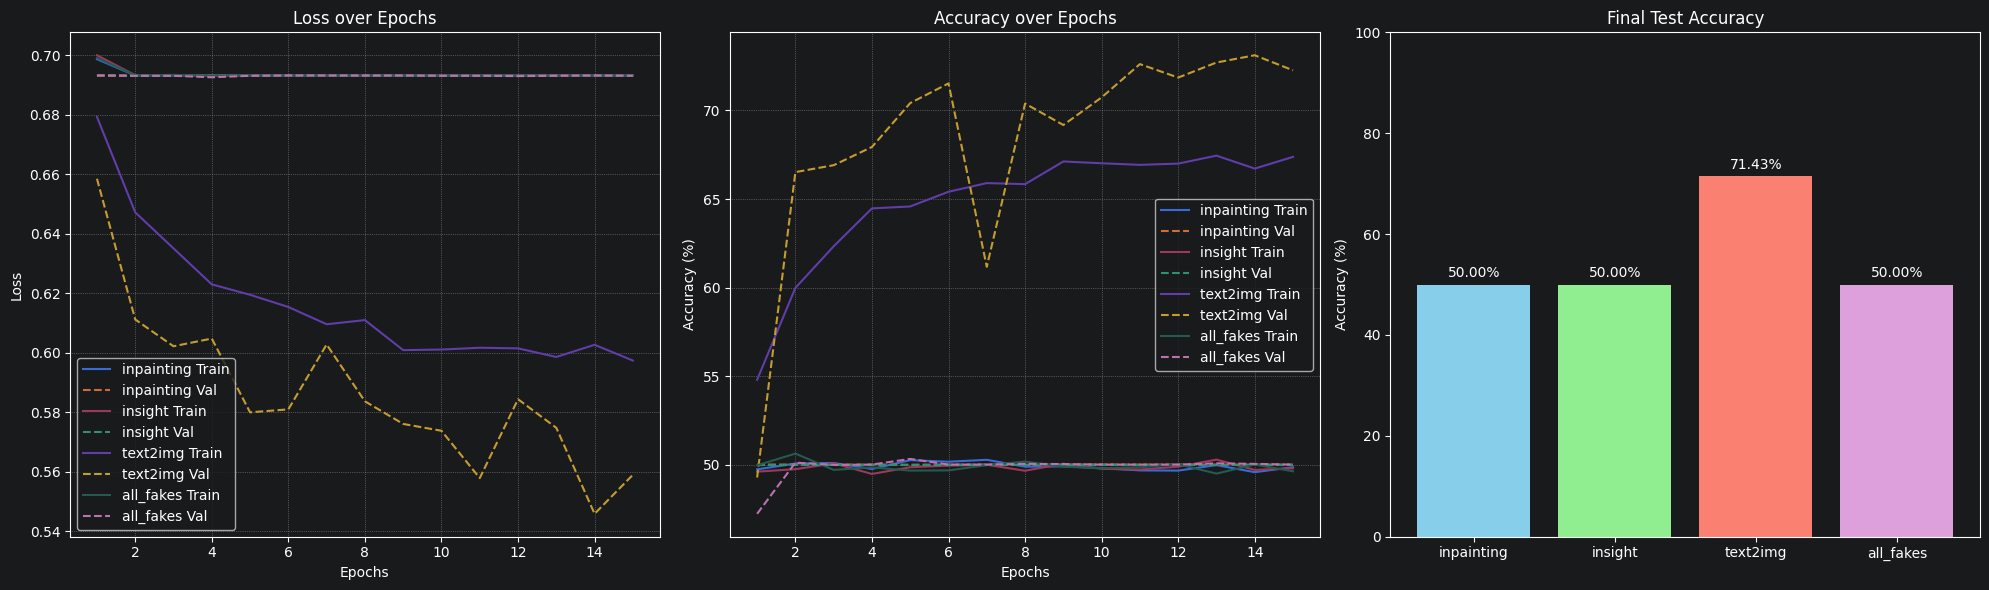

In [13]:
log_file_path = os.path.join("experiment_logs", "NN_1", "logs.txt")

# Check if both dictionaries exist in memory AND have data in them
if ('all_histories' in locals() and all_histories) and ('all_test_metrics' in locals() and all_test_metrics):
    plot_experiment_results(
        histories_dict=all_histories,
        test_metrics_dict=all_test_metrics,
        log_filepath=None
    )
else:
    plot_experiment_results(
        histories_dict=None,
        test_metrics_dict=None,
        log_filepath=log_file_path
    )

### CNN


#### ResNet

#### Fine Tuning All Layers

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_resnet_models = {}
all_resnet_histories = {}
all_resnet_test_metrics = {}

model_name = "ResNet34_full"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (224, 224)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type="resnet",
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeResNet34(freeze_features=False).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_resnet_models[experiment_name] = trained_model
    all_resnet_histories[experiment_name] = train_history
    all_resnet_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 RESNET_FULL EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda
Skipping INPAINTING: Results already found in experiment_logs/ResNet34_full/logs.txt
Skipping INSIGHT: Results already found in experiment_logs/ResNet34_full/logs.txt
Skipping TEXT2IMG: Results already found in experiment_logs/ResNet34_full/logs.txt
Skipping ALL_FAKES: Results already found in experiment_logs/ResNet34_full/logs.txt

 ALL 4 RESNET_FULL EXPERIMENTS COMPLETED SUCCESSFULLY!


Fetching plot data directly from logs: experiment_logs/ResNet34_full/logs.txt


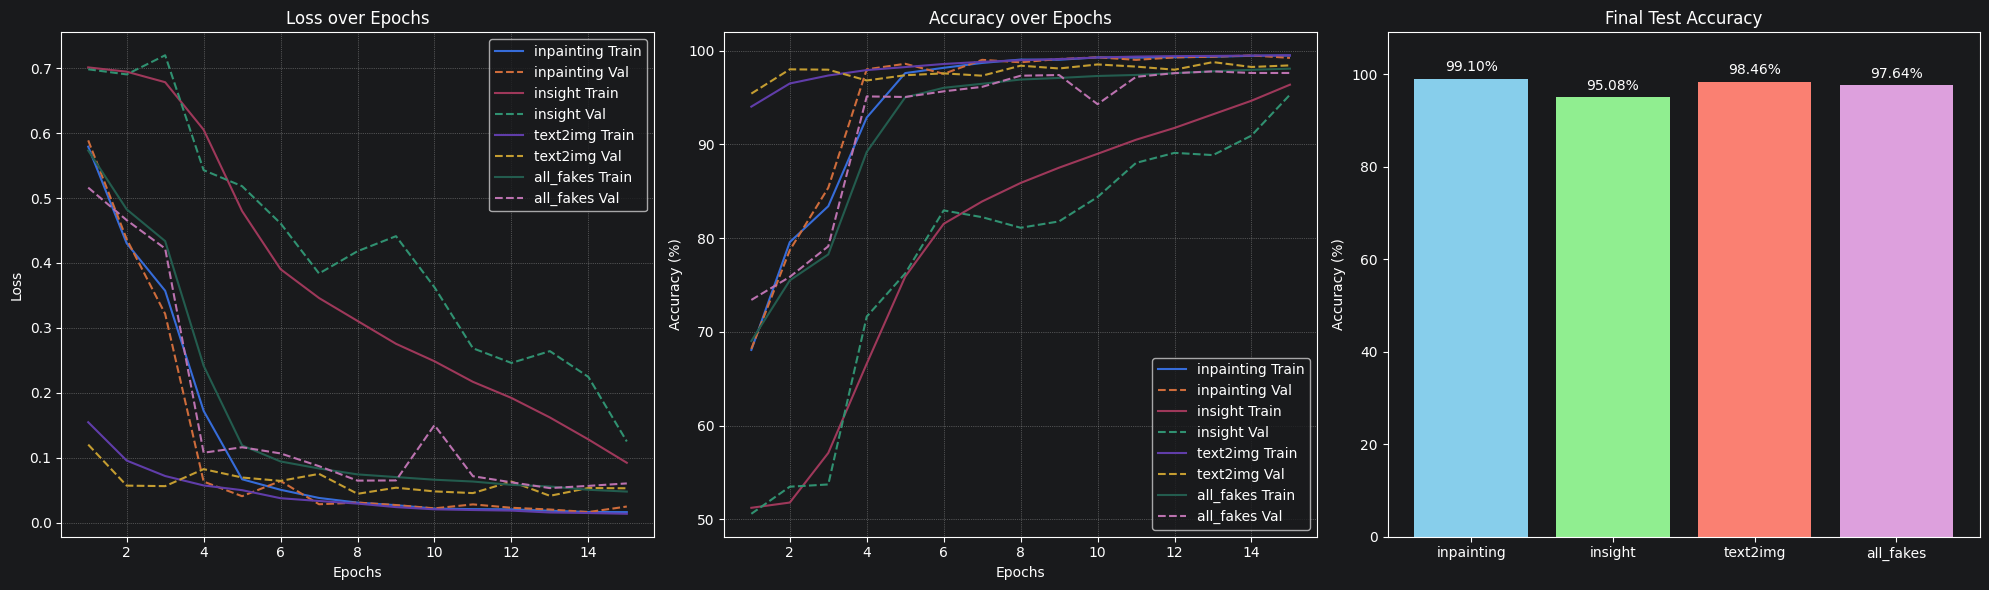

In [15]:
resnet_log_path = os.path.join("experiment_logs", "ResNet34_full", "logs.txt")

if ('all_resnet_histories' in locals() and all_resnet_histories) and ('all_resnet_test_metrics' in locals() and all_resnet_test_metrics):
    plot_experiment_results(histories_dict=all_resnet_histories, test_metrics_dict=all_resnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=resnet_log_path)

#### Fine Tuning Last Layer

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_resnet_frozen_models = {}
all_resnet_frozen_histories = {}
all_resnet_frozen_test_metrics = {}

model_name = "ResNet34_frozen"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (224, 224)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type="resnet",
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeResNet34(freeze_features=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_resnet_frozen_models[experiment_name] = trained_model
    all_resnet_frozen_histories[experiment_name] = train_history
    all_resnet_frozen_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 RESNET_FROZEN EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda
Skipping INPAINTING: Results already found in experiment_logs/ResNet34_frozen/logs.txt
Skipping INSIGHT: Results already found in experiment_logs/ResNet34_frozen/logs.txt
Skipping TEXT2IMG: Results already found in experiment_logs/ResNet34_frozen/logs.txt
Skipping ALL_FAKES: Results already found in experiment_logs/ResNet34_frozen/logs.txt

 ALL 4 RESNET_FROZEN EXPERIMENTS COMPLETED SUCCESSFULLY!


Fetching plot data directly from logs: experiment_logs/ResNet34_frozen/logs.txt


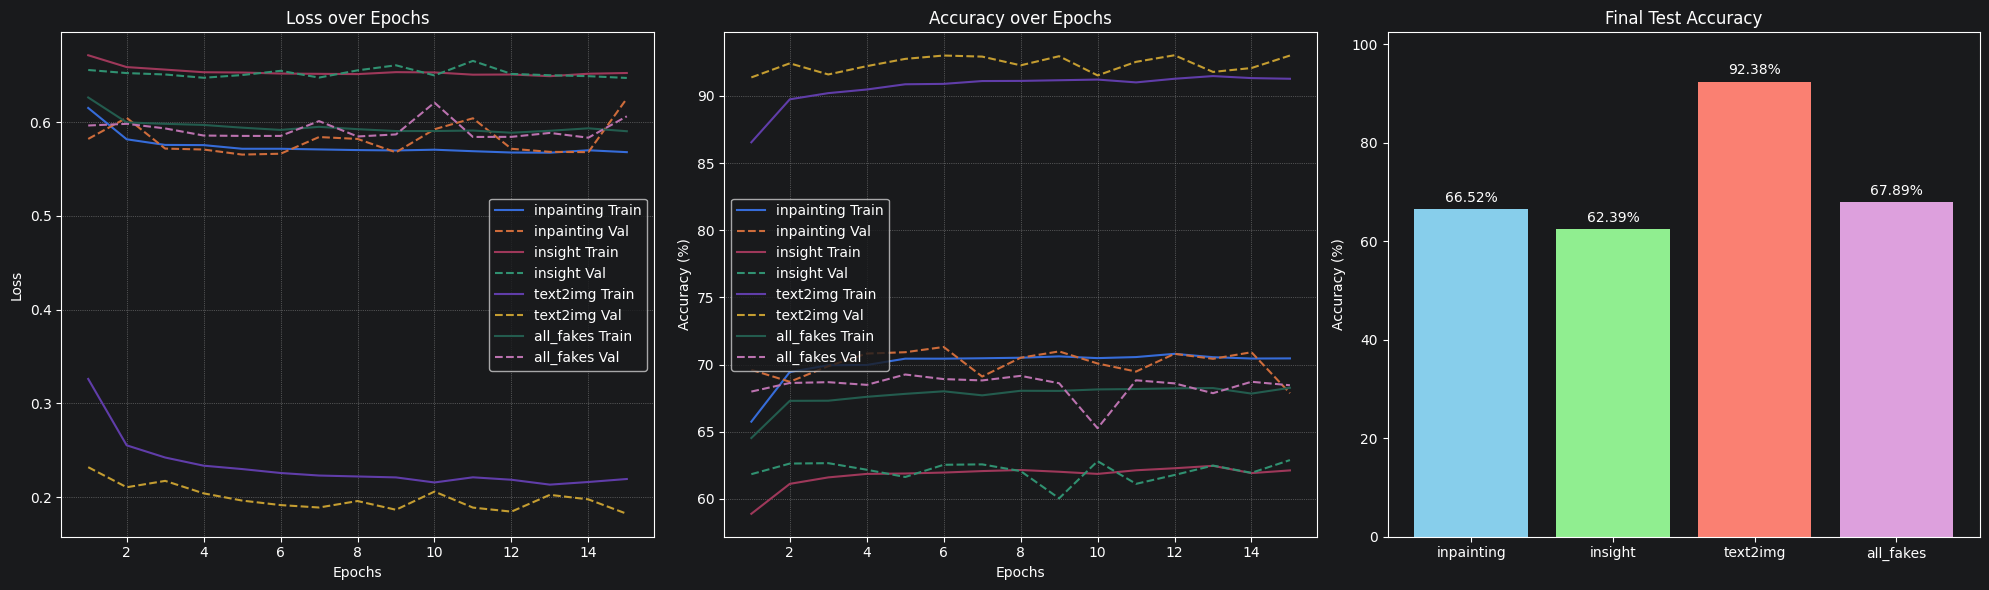

In [17]:
resnet_log_path = os.path.join("experiment_logs", "ResNet34_frozen", "logs.txt")

if ('all_resnet_frozen_histories' in locals() and all_resnet_frozen_histories) and ('all_resnet_frozen_test_metrics' in locals() and all_resnet_frozen_test_metrics):
    plot_experiment_results(histories_dict=all_resnet_frozen_histories, test_metrics_dict=all_resnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=resnet_log_path)

### EfficientNet

#### Fine Tunning All Layers

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_efficientnet_models = {}
all_efficientnet_histories = {}
all_efficientnet_test_metrics = {}

model_name = "EfficientNet_full"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (224, 224)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type="resnet",
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeEfficientNet(freeze_features=False).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_efficientnet_models[experiment_name] = trained_model
    all_efficientnet_histories[experiment_name] = train_history
    all_efficientnet_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 EFFICIENTNET_FULL EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda

STARTING EXPERIMENT: INPAINTING
Building DataFrames...
Using ONLY fake category: inpainting
Splitting Data (70% Train, 15% Val, 15% Test)...
Setting up Transforms and DataLoaders...
 -> Applying ImageNet Normalization for ResNet.
Pipeline Complete!

Number of training batches: 1313
Number of validation batches: 282
Number of test batches:       282
Starting experiment: inpainting


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 2.94 GiB of which 20.81 MiB is free. Including non-PyTorch memory, this process has 2.91 GiB memory in use. Of the allocated memory 2.70 GiB is allocated by PyTorch, and 145.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
efficientnet_log_path = os.path.join("experiment_logs", "EfficientNet_full", "logs.txt")

if ('all_efficientnet_histories' in locals() and all_efficientnet_histories) and ('all_efficientnet_test_metrics' in locals() and all_efficientnet_test_metrics):
    plot_experiment_results(histories_dict=all_efficientnet_histories, test_metrics_dict=all_efficientnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=efficientnet_log_path)

#### Fine Tuning Last Layer

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_efficientnet_frozen_models = {}
all_efficientnet_frozen_histories = {}
all_efficientnet_frozen_test_metrics = {}

model_name = "EfficientNet_frozen"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (224, 224)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type="resnet",
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeEfficientNet(freeze_features=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_efficientnet_frozen_models[experiment_name] = trained_model
    all_efficientnet_frozen_histories[experiment_name] = train_history
    all_efficientnet_frozen_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 EFFICIENTNET_FROZEN EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda

STARTING EXPERIMENT: INPAINTING
Building DataFrames...
Using ONLY fake category: inpainting
Splitting Data (70% Train, 15% Val, 15% Test)...
Setting up Transforms and DataLoaders...
 -> Applying ImageNet Normalization for ResNet.
Pipeline Complete!

Number of training batches: 1313
Number of validation batches: 282
Number of test batches:       282
Starting experiment: inpainting
Finished Epoch 1:
  TRAIN -> Loss 0.5831, Accuracy 69.04%, Precision 0.6934, Recall 0.6828, F1 0.6880, ROC-AUC 0.7591, TP 14338, TN 14660, FP 6340, FN 6662
  VAL   -> Loss 0.5467, Accuracy 71.84%, Precision 0.7419, Recall 0.6700, F1 0.7041, ROC-AUC 0.7987, TP 3015, TN 3451, FP 1049, FN 1485
Finished Epoch 2:
  TRAIN -> Loss 0.5622, Accuracy 70.71%, Precision 0.7082, Recall 0.7045, F1 0.7064, ROC-AUC 0.7809, TP 14795, TN 14904, FP 6096, FN 6205
  VAL   -> Loss 0.5387, Accuracy 72.37%, Precision 0.7466, Recall 0.6771, F1 0.7102, ROC-AUC 0.8064, TP 3047, TN 3466, FP 1034, FN 1453
Finished Epoc

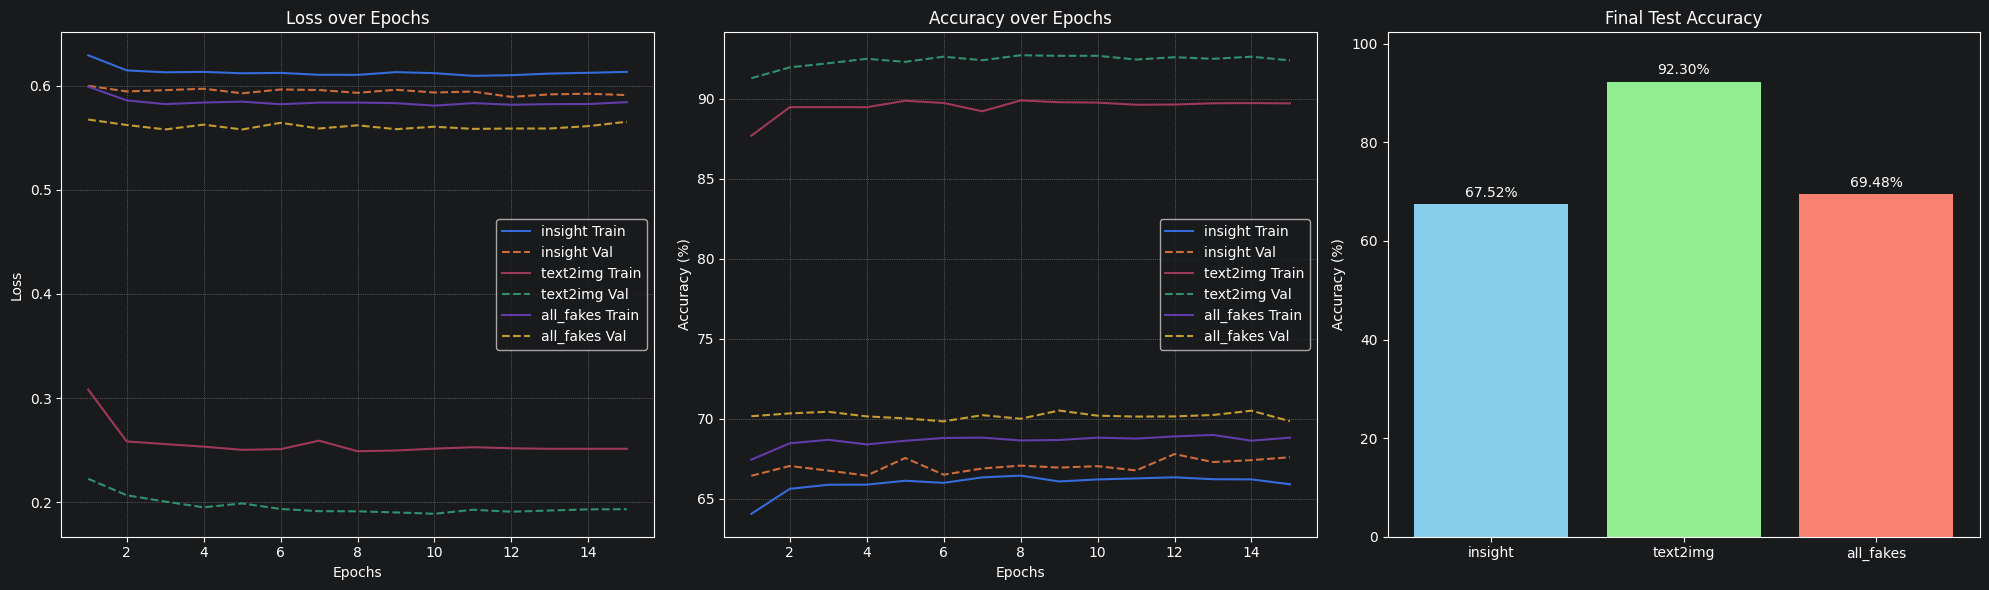

In [19]:
efficientnet_log_path = os.path.join("experiment_logs", "EfficientNet_frozen", "logs.txt")

if ('all_efficientnet_frozen_histories' in locals() and all_efficientnet_frozen_histories) and ('all_efficientnet_frozen_test_metrics' in locals() and all_efficientnet_frozen_test_metrics):
    plot_experiment_results(histories_dict=all_efficientnet_frozen_histories, test_metrics_dict=all_efficientnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=efficientnet_log_path)

#### Xception

#### Fine Tuning All Layers

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_xception_models = {}
all_xception_histories = {}
all_xception_test_metrics = {}

model_name = "Xception_full"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (299, 299)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type='xception',
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeXception(freeze_features=False).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_xception_models[experiment_name] = trained_model
    all_xception_histories[experiment_name] = train_history
    all_xception_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 XCEPTION_FULL EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda

STARTING EXPERIMENT: INPAINTING
Building DataFrames...
Using ONLY fake category: inpainting
Splitting Data (70% Train, 15% Val, 15% Test)...
Setting up Transforms and DataLoaders...
 -> Applying Xception [-1, 1] Normalization.
Pipeline Complete!

Number of training batches: 1313
Number of validation batches: 282
Number of test batches:       282
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /home/joao-proenca/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Starting experiment: inpainting


OutOfMemoryError: CUDA out of memory. Tried to allocate 172.00 MiB. GPU 0 has a total capacity of 2.94 GiB of which 54.81 MiB is free. Including non-PyTorch memory, this process has 2.88 GiB memory in use. Of the allocated memory 2.57 GiB is allocated by PyTorch, and 244.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
xception_log_path = os.path.join("experiment_logs", "Xception_full", "logs.txt")

if ('all_xception_histories' in locals() and all_xception_histories) and ('all_xception_test_metrics' in locals() and all_xception_test_metrics):
    plot_experiment_results(histories_dict=all_xception_histories, test_metrics_dict=all_xception_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=xception_log_path)

#### Fine Tuning Last Layer

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

all_xception_frozen_models = {}
all_xception_frozen_histories = {}
all_xception_frozen_test_metrics = {}

model_name = "Xception_frozen"
base_log_dir = "experiment_logs"

model_dir = os.path.join(base_log_dir, model_name)
os.makedirs(model_dir, exist_ok=True)
log_file = os.path.join(model_dir, "logs.txt")

img_size = (299, 299)
folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=img_size,
        fake_index=fake_idx,
        model_type='xception',
        balance=(fake_idx == 3)
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    model = DeepFakeXception(freeze_features=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name=model_name,
        base_log_dir=base_log_dir,
        epochs=15
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_xception_frozen_models[experiment_name] = trained_model
    all_xception_frozen_histories[experiment_name] = train_history
    all_xception_frozen_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 XCEPTION_FROZEN EXPERIMENTS COMPLETED SUCCESSFULLY!")

Using device: cuda

STARTING EXPERIMENT: INPAINTING
Building DataFrames...
Using ONLY fake category: inpainting
Splitting Data (70% Train, 15% Val, 15% Test)...
Setting up Transforms and DataLoaders...
 -> Applying Xception [-1, 1] Normalization.
Pipeline Complete!

Number of training batches: 1313
Number of validation batches: 282
Number of test batches:       282
Starting experiment: inpainting
Finished Epoch 1:
  TRAIN -> Loss 0.6289, Accuracy 64.60%, Precision 0.6487, Recall 0.6369, F1 0.6427, ROC-AUC 0.7024, TP 13374, TN 13758, FP 7242, FN 7626
  VAL   -> Loss 0.6097, Accuracy 66.64%, Precision 0.7034, Recall 0.5756, F1 0.6331, ROC-AUC 0.7349, TP 2590, TN 3408, FP 1092, FN 1910
Finished Epoch 2:
  TRAIN -> Loss 0.5971, Accuracy 68.19%, Precision 0.6867, Recall 0.6689, F1 0.6777, ROC-AUC 0.7456, TP 14047, TN 14592, FP 6408, FN 6953
  VAL   -> Loss 0.5986, Accuracy 68.33%, Precision 0.6659, Recall 0.7358, F1 0.6991, ROC-AUC 0.7463, TP 3311, TN 2839, FP 1661, FN 1189
Finished Epoch 3

KeyboardInterrupt: 

In [ ]:
xception_log_path = os.path.join("experiment_logs", "Xception_frozen", "logs.txt")

if ('all_xception_frozen_histories' in locals() and all_xception_frozen_histories) and ('all_xception_frozen_test_metrics' in locals() and all_xception_frozen_test_metrics):
    plot_experiment_results(histories_dict=all_xception_frozen_histories, test_metrics_dict=all_xception_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=xception_log_path)